# BDT Training (XGBoost)

<div style="text-align: justify">

The following notebook is dedicated to supervised machine learning training for the <b>Tau Supersymmetry</b> search analysis. A gradient-boosted decision tree classifier is trained using <b>XGBoost</b> on the rectangular MC DataFrame produced by the feature engineering pipeline. Two split strategies are supported: a single stratified train/test split and stratified K-fold cross-validation.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis and model configuration |
| MLflow | `mlflow` | Start run and log hyperparameters |
| Load | `io.load_dataframe` | Read mc.parquet from feature engineering output |
| Labels | — | Derive ordered class names from `eventOrigin` |
| Prepare | `splits.prepare_features_target` | Separate training features, labels, and weights |
| Split | `splits.train_test_split` / `splits.kfold_split` | Stratified train/test or K-fold split |
| Params | `bdt.build_params` | Build XGBoost kwargs from Hydra config |
| Train | `bdt.train` / `bdt.train_kfold` | Fit model(s) with early stopping |
| Curves | `models.plots.plot_training_curves` | Visualise convergence |
| Predict | `bdt.predict` | Compute hard predictions and probability scores |
| Save | `bdt.save_model`, `io.save_dataframe` | Persist model and predictions parquet |

The same pipeline is available as a CLI via `python run.py stage=train` or `make train`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)
* [NumPy](https://numpy.org/)

Data Visualization:
* [Matplotlib](https://matplotlib.org/)

Machine Learning:
* [XGBoost](https://xgboost.readthedocs.io/en/stable/)
* [scikit-learn](https://scikit-learn.org/stable/)

Experiment Tracking:
* [MLflow](https://mlflow.org/)

Serialization:
* [Apache Parquet](https://parquet.apache.org/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

## Configuration

Loading the Hydra configuration.  All analysis parameters (run, region, channel, model hyperparameters, split strategy) are defined in `configs/` and can be overridden here.

> **Device note:** the model config defaults to `device: cuda`. Change it to `device: cpu` for local CPU execution.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config")

## MLflow

Starting the MLflow run and logging all model hyperparameters and pipeline parameters.

In [5]:
import logging

import mlflow
from omegaconf import OmegaConf

logging.getLogger("mlflow").setLevel(logging.WARNING)
logging.getLogger("alembic").setLevel(logging.WARNING)

mlflow.set_tracking_uri(f"file://{path}/mlruns")
mlflow.set_experiment(cfg.get("experiment_name", "tau-supersymmetry-search-bdt"))
run = mlflow.start_run()

mlflow.log_params(OmegaConf.to_container(cfg.model, resolve=True))
mlflow.log_params({
    "split_strategy": cfg.pipeline.split_strategy,
    "n_splits": cfg.pipeline.n_splits,
    "early_stopping_rounds": cfg.pipeline.early_stopping_rounds,
    "test_split": cfg.data.test_split,
    "seed": cfg.seed,
})
print(f"MLflow run ID: {run.info.run_id}")

MLflow run ID: 74ac18566b764658beffdc877aaf7624


Resolving input and output directories from config.

In [6]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
models_dir = path / output_paths["models_dir"]
plots_dir = path / output_paths["plots_dir"] / "bdt"

models_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

## Deserialization

Loading the MC DataFrame produced by the feature engineering pipeline.

In [7]:
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")
print(f"Loaded: {len(df_mc):,} events, {len(df_mc.columns)} columns")

Loaded: 9,827,169 events, 58 columns


Deriving ordered class names and display labels from `eventOrigin`.

In [8]:
from omegaconf import OmegaConf
from src.eda.utils import get_class_names, get_class_labels

display_labels = OmegaConf.to_container(cfg.merge.display_labels, resolve=True)
class_names = get_class_names(df_mc)
class_labels = get_class_labels(df_mc, display_labels=display_labels)
n_classes = len(class_names)
print(f"Classes ({n_classes}): {class_names}")
class_labels

Classes (6): ['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']


['top quarks',
 '$W \\rightarrow \\tau\\nu$',
 '$Z \\rightarrow \\tau\\tau$',
 'diboson',
 'other',
 'signal']

In [9]:
mlflow.log_param("n_classes", n_classes)
mlflow.log_param("class_names", class_names)

['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']

## Training Preparation

### Features & Target

Separating training features, integer class labels, and per-event sample weights. Non-training metadata columns (`class`, `class_weight`, `tau_n`, `eventOrigin`) are excluded from the feature matrix.

In [10]:
from src.models.splits import prepare_features_target

X, y, weights = prepare_features_target(df_mc)
print(f"Feature matrix: {X.shape}")
print(f"Class distribution:\n{y.value_counts().sort_index().rename(index=dict(enumerate(class_names)))}")

Feature matrix: (9827169, 53)
Class distribution:
class
topquarks    1139269
wtaunu       1716897
ztautau      2314192
diboson      1846720
other         824018
signal       1986073
Name: count, dtype: int64


In [11]:
mlflow.log_param("n_features", X.shape[1])

53

### Train / Test Split

Splitting the dataset according to the strategy defined in `configs/pipeline/default.yaml` (`split_strategy`). Both strategies use stratified sampling to preserve the class distribution.

* **`train_test`** — single stratified split with `test_split` fraction held out.
* **`k_fold`** — stratified K-fold; each fold's test set is non-overlapping, giving out-of-fold (OOF) coverage of the full dataset.

In [12]:
from src.models.splits import train_test_split, kfold_split

split_strategy = cfg.pipeline.split_strategy

if split_strategy == "train_test":
    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, weights,
        test_size=cfg.data.test_split,
        seed=cfg.seed,
    )
    print(f"Train: {len(X_train):,} events | Test: {len(X_test):,} events")

elif split_strategy == "k_fold":
    folds = kfold_split(X, y, weights, n_splits=cfg.pipeline.n_splits, seed=cfg.seed)
    print(f"K-fold: {cfg.pipeline.n_splits} stratified folds")

else:
    raise ValueError(f"Unknown split_strategy: {split_strategy!r}")

Train: 7,861,735 events | Test: 1,965,434 events


## Training

Building XGBoost constructor parameters from the Hydra model config. The objective and evaluation metric are set automatically based on the number of classes.

In [13]:
from src.models.bdt import build_params

params = build_params(cfg, n_classes=n_classes)
metric = params["eval_metric"]
params

{'booster': 'gbtree',
 'n_estimators': 10000,
 'learning_rate': 0.032,
 'max_depth': 8,
 'min_child_weight': 4,
 'gamma': 0.0016,
 'subsample': 0.84,
 'colsample_bytree': 0.96,
 'reg_alpha': 0.00024,
 'reg_lambda': 0.0089,
 'max_delta_step': 0,
 'tree_method': 'hist',
 'device': 'cuda',
 'seed': 1,
 'verbosity': 0,
 'objective': 'multi:softproba',
 'eval_metric': 'mlogloss',
 'num_class': 6}

Training the model with early stopping. Both the training and validation sets are monitored; XGBoost stops when the validation metric does not improve for `early_stopping_rounds` consecutive rounds.

In [14]:
from src.models.bdt import get_evals_result, train, train_kfold

if split_strategy == "train_test":
    model = train(
        params,
        X_train, y_train,
        X_test, y_test,
        w_train=w_train,
        early_stopping_rounds=cfg.pipeline.early_stopping_rounds,
    )
    print(f"Best iteration : {model.best_iteration}")
    print(f"Best val score : {model.best_score:.6f}")

    mlflow.log_metric("best_iteration", model.best_iteration)
    mlflow.log_metric(f"best_val_{metric}", model.best_score)

    evals = get_evals_result(model)
    for step, (train_val, val_val) in enumerate(
        zip(evals["validation_0"][metric], evals["validation_1"][metric])
    ):
        mlflow.log_metric(f"train_{metric}", train_val, step=step)
        mlflow.log_metric(f"val_{metric}", val_val, step=step)

elif split_strategy == "k_fold":
    models, y_pred, y_proba, y_test = train_kfold(
        params,
        folds,
        early_stopping_rounds=cfg.pipeline.early_stopping_rounds,
    )
    print(f"Trained {len(models)} folds")
    best_iters = [m.best_iteration for m in models]
    print(f"Best iterations per fold: {best_iters}")

    for fold_idx, m in enumerate(models):
        mlflow.log_metric("best_iteration", m.best_iteration, step=fold_idx)
        mlflow.log_metric(f"best_val_{metric}", m.best_score, step=fold_idx)

Training:   0%|          | 0/10000 [00:00<?, ?tree/s]

Best iteration : 9995
Best val score : 0.905501


## Training Curves

Plotting per-round training and validation loss.  The vertical dashed line marks the best iteration selected by early stopping.

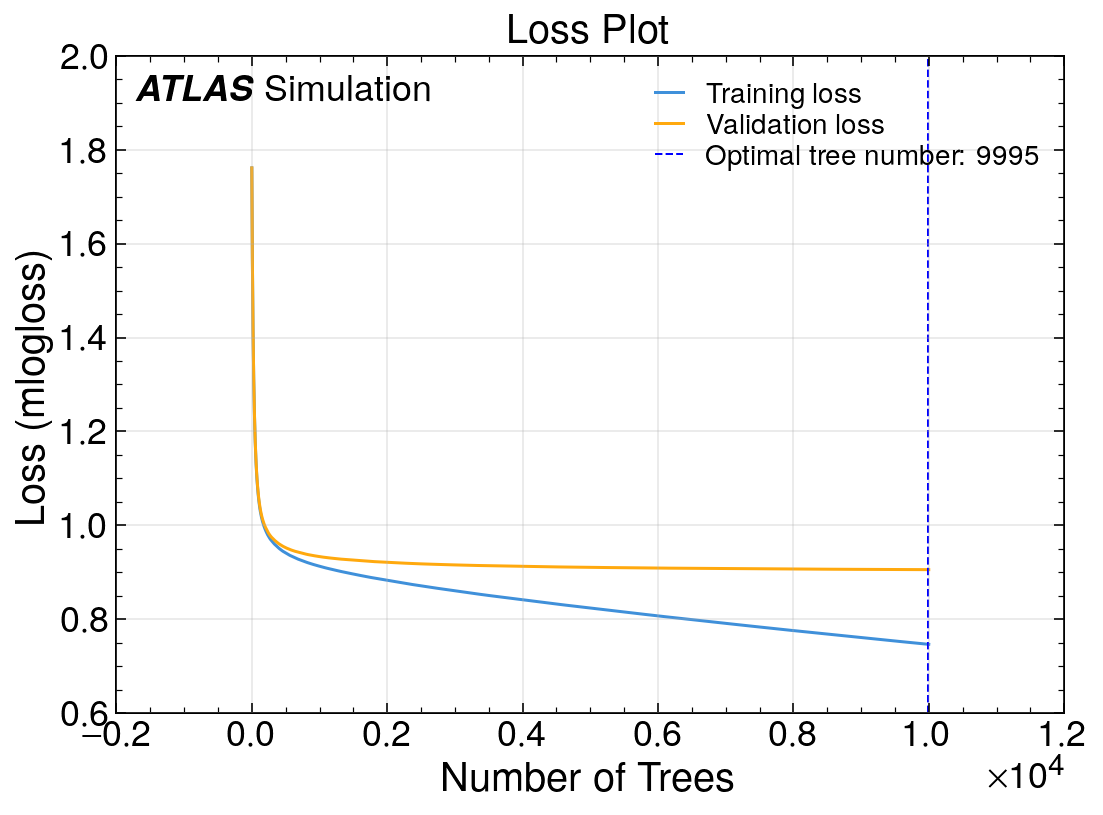

In [15]:
from src.models.plots import plot_training_curves, plot_kfold_training_curves
from src.visualization.plots import save_figure

if split_strategy == "train_test":
    fig = plot_training_curves(evals, metric=metric)
    curve_path = plots_dir / "training_curves.png"
    save_figure(fig, curve_path)
    mlflow.log_artifact(str(curve_path))
    fig.show()

elif split_strategy == "k_fold":
    fig = plot_kfold_training_curves(models, metric=metric)
    curve_path = plots_dir / "training_curves_kfold.png"
    save_figure(fig, curve_path)
    mlflow.log_artifact(str(curve_path))
    fig.show()

## Predictions

Computing hard predictions and per-class probability scores on the test set.

In [16]:
from src.models.bdt import predict, build_predictions_frame

if split_strategy == "train_test":
    y_pred, y_proba = predict(model, X_test)

predictions_df = build_predictions_frame(y_test, y_pred, y_proba, class_names)
print(f"Predictions DataFrame: {predictions_df.shape}")
predictions_df.head()

Predictions DataFrame: (1965434, 8)


,y_true,y_pred,p_topquarks,p_wtaunu,p_ztautau,p_diboson,p_other,p_signal
0,5,5,0.000020,0.000002,0.000002,0.000101,0.000024,0.999851
1,5,5,0.002594,0.001175,0.006176,0.012990,0.001535,0.975531
2,3,3,0.089320,0.389913,0.065544,0.445422,0.008497,0.001305
3,2,2,0.037785,0.245120,0.481704,0.220879,0.009138,0.005375
4,0,4,0.374935,0.012957,0.004540,0.026915,0.572750,0.007903


## Serialization

Saving the trained model and the test-set predictions.  The predictions parquet is consumed by the downstream evaluation step.

In [17]:
from src.models.bdt import save_model
from src.processing.io import save_dataframe

if cfg.pipeline.save_model:
    if split_strategy == "train_test":
        model_path = models_dir / "bdt.ubj"
        save_model(model, model_path)
        mlflow.log_artifact(str(model_path))
    elif split_strategy == "k_fold":
        for fold_idx, m in enumerate(models):
            model_path = models_dir / f"bdt_fold{fold_idx}.ubj"
            save_model(m, model_path)
            mlflow.log_artifact(str(model_path))

predictions_path = dataframes_dir / "bdt_predictions.parquet"
save_dataframe(predictions_df, predictions_path)
mlflow.log_artifact(str(predictions_path))

mlflow.end_run()

TypeError: `_estimator_type` undefined.  Please use appropriate mixin to define estimator type.